In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
x = np.linspace(-5.0,5.0,100)
y = np.sqrt(10**2 - x**2 )
y = np.hstack([y,-y])
x = np.hstack([x,-x])

In [5]:
x1 = np.linspace(-5.0,5.0,100)
y1 = np.sqrt(5**2 - x1**2 )
y1 = np.hstack([y1,-y1])
x1 = np.hstack([x1,-x1])

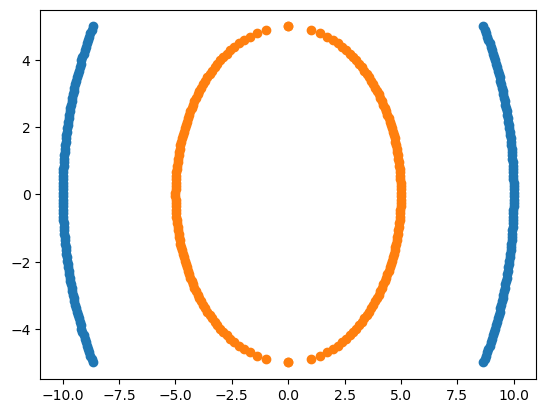

In [6]:
plt.scatter(y,x)
plt.scatter(y1,x1)

In [7]:
df1 = pd.DataFrame(
    np.vstack([x, y]).T,
    columns=["X1", "X2"]
)
df1["Y"] = 0

df2 = pd.DataFrame(
    np.vstack([x1, y1]).T,
    columns=["X1", "X2"]
)
df2["Y"] = 1

df = pd.concat([df1,df2] , ignore_index = True)
print(df.head())

        X1        X2  Y
0 -5.00000  8.660254  0
1 -4.89899  8.717792  0
2 -4.79798  8.773790  0
3 -4.69697  8.828277  0
4 -4.59596  8.881281  0


In [9]:
#BReak the data into independent and depeneent
X = df.iloc[:,:2]
y = df.Y
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [14]:
#split the dataset
from sklearn.model_selection import train_test_split as tts 
X_train,X_test = tts(X,test_size=0.34,random_state=32)
y_train,y_test = tts(y,test_size=0.34,random_state=32)

In [15]:
y_train

29     0
301    1
72     0
121    0
392    1
      ..
380    1
310    1
389    1
43     0
215    1
Name: Y, Length: 264, dtype: int64

Making a Failing model with wrost accuracy using only Linear Kernel

In [16]:
from sklearn.svm import SVC
classifier = SVC(kernel= "linear") 
classifier.fit(X_train,y_train)

SVC(kernel='linear')

In [19]:
from sklearn.metrics import accuracy_score
y_pred  = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.4485294117647059

#Making a better scoring one using a different SVM Kernels


2. Linear kernel + Transformations :

To applt the kernel we need to find components first

In [ ]:
# WE know that using this kernel will multiply x * x(transpose) and increase the number of features
df["X1_square"] =df["X1"] **2 
df["X2_square"] =df["X2"] **2 
df["X1*X2"] =df["X1"] * df["X2"]
df.head() 

,X1,X2,Y,X1_square,X2_square,X1*X2
0,-5.00000,8.660254,0,25.000000,75.000000,-43.301270
1,-4.89899,8.717792,0,24.000102,75.999898,-42.708375
2,-4.79798,8.773790,0,23.020610,76.979390,-42.096467
3,-4.69697,8.828277,0,22.061524,77.938476,-41.466150
4,-4.59596,8.881281,0,21.122845,78.877155,-40.818009


Now we rebuild the data

In [29]:
new_X = df[[ "X1","X2","X1_square","X2_square","X1*X2"]] #new independent features
new_y = df["Y"] # same old tragets

In [30]:
#Train test split
new_X_train,new_X_test,new_y_train,new_y_test= tts(new_X,new_y,random_state= 25,test_size=0.21)

In [38]:
new_X

,X1,X2,X1_square,X2_square,X1*X2
0,-5.00000,8.660254,25.000000,75.000000,-43.301270
1,-4.89899,8.717792,24.000102,75.999898,-42.708375
2,-4.79798,8.773790,23.020610,76.979390,-42.096467
3,-4.69697,8.828277,22.061524,77.938476,-41.466150
4,-4.59596,8.881281,21.122845,78.877155,-40.818009
...,...,...,...,...,...
395,-4.59596,-1.969049,21.122845,3.877155,9.049671
396,-4.69697,-1.714198,22.061524,2.938476,8.051537
397,-4.79798,-1.406908,23.020610,1.979390,6.750316
398,-4.89899,-0.999949,24.000102,0.999898,4.898740


In [ ]:
#take a look at the old data set in 3D
import plotly.express as px 
fig  = px.scatter_3d(df,x= "X1",y = "X2",z = "X1*X2",color= "Y")
fig.show()

In [42]:
#take a look at the new data set in 3D
import plotly.express as px 
fig  = px.scatter_3d(df,x= "X1_square",y = "X2_square",z = "X1*X2",color= "Y")
fig.show()

As the Transformation clearly separated the data so that a clear hard hyperplane could be made 
Now the linear model will give 100% accuracy on the training data

In [35]:
from sklearn.svm import SVC
classifier = SVC(kernel= "linear") 
classifier.fit(new_X_train,new_y_train)

SVC(kernel='linear')

In [36]:
new_y_pred  = classifier.predict(new_X_test)
accuracy_score(new_y_test,new_y_pred)

1.0

OR If you dont want to do any of this just change the kernel

In [43]:
from sklearn.svm import SVC
classifier = SVC(kernel= "poly") 
classifier.fit(X_train,y_train)
y_pred  = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.6838235294117647

In [ ]:
#by default the rbf handles the expon
from sklearn.svm import SVC
classifier = SVC(kernel= "rbf") 
classifier.fit(X_train,y_train)
y_pred  = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

1.0

In [24]:
from sklearn.svm import SVC
classifier = SVC(kernel= "sigmoid") 
classifier.fit(X_train,y_train)
y_pred  = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.625